
# Practical 6: Evaluation Metrics for Classification, Detection, Segmentation

## Why this practical?
Training a model is **not enough**. We must **measure** how good it is.  
In this practical, you will learn **how to evaluate** models for three common tasks:
- **Image Classification**
- **Object Detection**
- **Semantic Segmentation**

We use **small, fast examples** so you can focus on **understanding the metrics**, not long training.



## Learning Objectives
By the end of this practical, you will be able to:
1. Compute **accuracy, precision, recall, F1**, and plot **confusion matrix**, **ROC**, and **PR** curves for classification.
2. Compute **IoU** for bounding boxes and understand **AP / mAP\@0.5** for object detection.
3. Compute **IoU (Jaccard)**, **Dice coefficient (F1)**, and **pixel accuracy** for semantic segmentation.
4. Choose **which metric** to use and **explain** why.



## 0) Setup
We will install and import the libraries we need. If you already have them, you can skip installation.


In [1]:

# If running in a fresh environment, uncomment these:
# !pip install -q numpy matplotlib scikit-learn tensorflow

import numpy as np
import matplotlib.pyplot as plt

# scikit-learn for classification metrics
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    precision_score, recall_score, f1_score
)



## 1) Classification Metrics (Multi-class example)

We simulate predictions for a **3-class** problem to keep it fast:
- **True labels**: ground-truth class for each image.
- **Predicted scores**: model confidence for each class (softmax-like).

From these we compute:
- **Accuracy:** Overall correctness.
- **Precision, Recall, F1 (macro):** Balance across classes.
- **Confusion Matrix:** Where the model makes mistakes.
- **ROC / PR curves:** Usually for **binary** or **one-vs-rest** views; we demonstrate for **Class 0**.


In [2]:

# ----- Simulate a small classification dataset -----
np.random.seed(42)
n = 200  # number of samples
n_classes = 3

# True labels (0,1,2)
y_true = np.random.randint(0, n_classes, size=n)

# Simulated predicted scores (softmax-like probabilities)
raw = np.random.randn(n, n_classes)
exp = np.exp(raw)
y_scores = exp / exp.sum(axis=1, keepdims=True)  # shape (n, 3)

# Predicted class = argmax of scores
y_pred = y_scores.argmax(axis=1)

# ----- Basic metrics -----
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")


Accuracy: 0.375
Precision: 0.375  Recall: 0.376  F1: 0.375



### What do Accuracy, Precision, Recall, F1 mean?
- **Accuracy**: how many predictions were correct overall.  
- **Precision (for a class)**: of the items predicted as this class, how many were truly this class?  
- **Recall (for a class)**: of all items that truly belong to this class, how many did we correctly find?  
- **F1**: a single score that balances precision and recall (harmonic mean).

**Small worked example (binary: Cat vs Dog):**

| Image | True | Pred |
|------:|:----:|:----:|
| 1 | Cat | Cat |
| 2 | Cat | Dog |
| 3 | Cat | Cat |
| 4 | Dog | Cat |
| 5 | Dog | Cat |
| 6 | Dog | Dog |
| 7 | Dog | Dog |
| 8 | Cat | Cat |

- **TP (Cat)** = 3, **FP (Cat)** = 2, **FN (Cat)** = 1, **TN (Cat)** = 2  
- **Accuracy** = (TP+TN)/8 = (3+2)/8 = **0.625 ≈ 0.63**  
- **Precision** = TP/(TP+FP) = 3/(3+2) = **0.60**  
- **Recall** = TP/(TP+FN) = 3/(3+1) = **0.75**  
- **F1** = 2·(P·R)/(P+R) = 2·(0.60·0.75)/(0.60+0.75) = **0.67**


In [ ]:

# Program the small Cat/Dog example to verify calculations
# Cat=1 (positive), Dog=0
y_true_ex = [1,1,1,0,0,0,0,1]
y_pred_ex = [1,0,1,1,1,0,0,1]  # precision=0.60, recall=0.75, f1≈0.67, accuracy≈0.63

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true_ex, y_pred_ex))
print("Accuracy :", round(accuracy_score(y_true_ex, y_pred_ex), 2))
print("Precision:", round(precision_score(y_true_ex, y_pred_ex), 2))
print("Recall   :", round(recall_score(y_true_ex, y_pred_ex), 2))
print("F1       :", round(f1_score(y_true_ex, y_pred_ex), 2))


Confusion matrix (rows=true, cols=pred):
[[2 2]
 [1 3]]
Accuracy : 0.62
Precision: 0.6
Recall   : 0.75
F1       : 0.67



### Confusion Matrix
Rows = **true** class, Columns = **predicted** class.


[[26 18 22]
 [20 23 18]
 [22 25 26]]


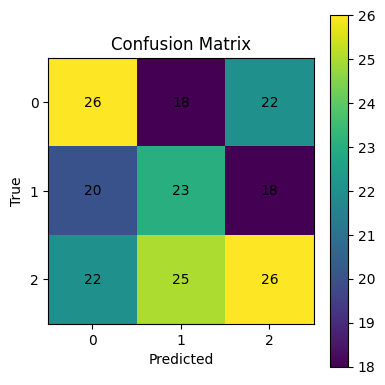

In [6]:

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
print(cm)

# Simple visualization without seaborn
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1,2]); plt.yticks([0,1,2])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()



**Reading the Confusion Matrix**  
Rows are **true** classes; columns are **predicted** classes.  
- The **diagonal** shows correct predictions.  
- Off-diagonal cells show **confusions** (where the model mixed classes).  
Use it to explain *which* classes are difficult for the model.



### ROC and PR Curves (One-vs-Rest)
For multi-class problems, we can draw ROC/PR curves **per class**.  
Here we show **Class 0 vs. the rest**.


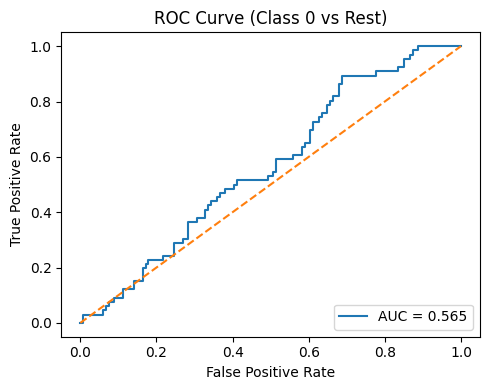

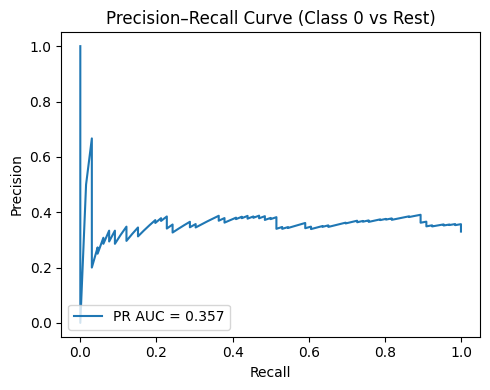

In [7]:

# One-vs-rest for class 0
y_true_bin = (y_true == 0).astype(int)
y_score_bin = y_scores[:, 0]

# ROC
fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0 vs Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision-Recall
precisions, recalls, _ = precision_recall_curve(y_true_bin, y_score_bin)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(5,4))
plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Class 0 vs Rest)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()



**ROC vs PR — when to use which?**  
- **ROC** (TPR vs FPR) is good when classes are **balanced**.  
- **PR** (Precision vs Recall) is more **informative for imbalanced data** (few positives).  
- **AUC** values summarize the area under each curve: higher = better.



## 2) Object Detection Metrics

For object detection, the common metrics are:
- **IoU (Intersection over Union)** between predicted and ground-truth boxes.
- **AP (Average Precision)** per class, and **mAP** (mean AP across classes).
- In this practical, we show a **simple mAP\@0.5** example (IoU threshold = 0.5).

First, let’s build intuition for **IoU** with a tiny visual.



### IoU (Intersection over Union) 

$$\mathrm{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

We draw a ground-truth box (solid) and a predicted box (dashed) and compute IoU.


IoU = 0.562


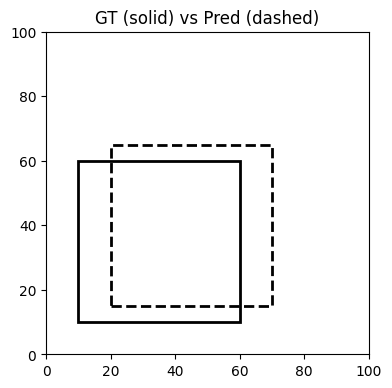

In [8]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_iou_demo(gt=(10,10,60,60), pred=(20,15,70,65)):
    def area(box):
        x1,y1,x2,y2 = box
        return max(0,x2-x1)*max(0,y2-y1)
    def inter(boxA, boxB):
        Ax1,Ay1,Ax2,Ay2 = boxA
        Bx1,By1,Bx2,By2 = boxB
        x1, y1 = max(Ax1,Bx1), max(Ay1,By1)
        x2, y2 = min(Ax2,Bx2), min(Ay2,By2)
        return max(0,x2-x1)*max(0,y2-y1)
    inter_area = inter(gt, pred)
    union_area = area(gt)+area(pred)-inter_area
    iou_val = inter_area/(union_area+1e-9)
    print(f"IoU = {iou_val:.3f}")
    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal')
    gx1,gy1,gx2,gy2 = gt
    ax.add_patch(patches.Rectangle((gx1,gy1), gx2-gx1, gy2-gy1, fill=False, linewidth=2))
    px1,py1,px2,py2 = pred
    ax.add_patch(patches.Rectangle((px1,py1), px2-px1, py2-py1, fill=False, linewidth=2, linestyle="--"))
    ax.set_title("GT (solid) vs Pred (dashed)")
    plt.tight_layout(); plt.show()

draw_iou_demo()



### From IoU to mAP\@0.5 (simple one-class demo)
We create a tiny dataset, sort predictions by score, compute **precision** and **recall**, and then compute **AP\@0.5**.  
With multiple classes, average AP across classes → **mAP\@0.5**.


Precision: [1.   1.   1.   0.75 0.6 ]
Recall   : [0.333 0.667 1.    1.    1.   ]
AP@0.5   : 0.667  (mAP@0.5 averages AP across classes; here we have one class)


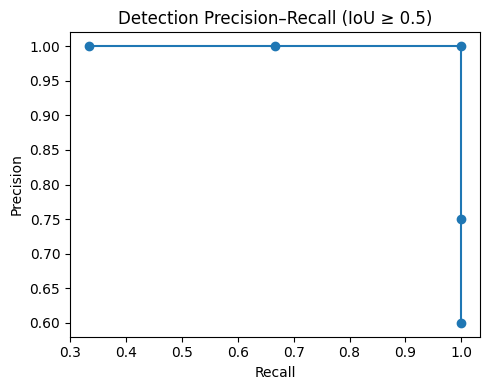

In [9]:

from dataclasses import dataclass

@dataclass
class Box:
    xmin: float; ymin: float; xmax: float; ymax: float  # (xmin, ymin, xmax, ymax)

def iou(box_a: Box, box_b: Box) -> float:
    x1 = max(box_a.xmin, box_b.xmin)
    y1 = max(box_a.ymin, box_b.ymin)
    x2 = min(box_a.xmax, box_b.xmax)
    y2 = min(box_a.ymax, box_b.ymax)
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = max(0.0, box_a.xmax - box_a.xmin) * max(0.0, box_a.ymax - box_a.ymin)
    area_b = max(0.0, box_b.xmax - box_b.xmin) * max(0.0, box_b.ymax - box_b.ymin)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

# Tiny dataset: 3 images, 1 GT per image
gt = {
    0: [Box(10,10,60,60)],
    1: [Box(15,20,55,65)],
    2: [Box(30,30,80,80)],
}

# Predictions: (image_id, box, score)
preds = [
    (0, Box(12,12,58,58), 0.95),
    (0, Box(0,0,20,20),   0.30),   # low IoU, likely FP
    (1, Box(10,18,54,64), 0.90),
    (2, Box(32,32,79,79), 0.60),
    (2, Box(0,0,10,10),   0.40),   # FP
]

# Sort by score desc
preds = sorted(preds, key=lambda x: x[2], reverse=True)

# Evaluate at IoU >= 0.5
iou_thr = 0.5
tp, fp = [], []
matched = {img_id: np.zeros(len(gt_boxes), dtype=bool) for img_id, gt_boxes in gt.items()}

for (img_id, pb, score) in preds:
    best_iou = 0.0
    best_j = -1
    for j, gb in enumerate(gt[img_id]):
        if not matched[img_id][j]:
            ov = iou(pb, gb)
            if ov > best_iou:
                best_iou, best_j = ov, j
    if best_iou >= iou_thr and best_j >= 0:
        tp.append(1); fp.append(0)
        matched[img_id][best_j] = True
    else:
        tp.append(0); fp.append(1)

tp = np.array(tp); fp = np.array(fp)

cum_tp = np.cumsum(tp)
cum_fp = np.cumsum(fp)
recall = cum_tp / sum(len(v) for v in gt.values())
precision = cum_tp / (cum_tp + cum_fp + 1e-9)

from sklearn.metrics import auc
AP = auc(recall, precision)

print("Precision:", np.round(precision, 3))
print("Recall   :", np.round(recall, 3))
print(f"AP@0.5   : {AP:.3f}  (mAP@0.5 averages AP across classes; here we have one class)")

plt.figure(figsize=(5,4))
plt.plot(recall, precision, marker="o")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Detection Precision–Recall (IoU ≥ 0.5)")
plt.tight_layout()
plt.show()



**Why AP/mAP, not just IoU?**  
Detectors output many boxes with **scores**. As we lower the score threshold, **recall** increases but **precision** may drop.  
**AP** is the area under the **Precision–Recall** curve for a class. **mAP** averages AP across classes (e.g., mAP\@0.5).



## 3) Semantic Segmentation Metrics (Binary mask example)

Common metrics:
- **Pixel Accuracy**
- **IoU (Jaccard index)**
- **Dice coefficient (F1 score for masks)**



### IoU vs Dice for Segmentation (small 5×5 masks)
- **IoU** = TP / (TP + FP + FN)  
- **Dice** = 2·TP / (2·TP + FP + FN)  (similar to F1 for masks)  
Dice is usually **higher** than IoU for the same prediction but they move together.


TP, FP, FN: 5 1 1
IoU : 0.714
Dice: 0.833


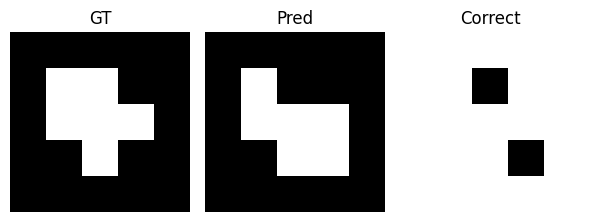

In [10]:

import numpy as np
import matplotlib.pyplot as plt

gt5 = np.array([
    [0,0,0,0,0],
    [0,1,1,0,0],
    [0,1,1,1,0],
    [0,0,1,0,0],
    [0,0,0,0,0],
], dtype=np.uint8)

pred5 = np.array([
    [0,0,0,0,0],
    [0,1,0,0,0],
    [0,1,1,1,0],
    [0,0,1,1,0],
    [0,0,0,0,0],
], dtype=np.uint8)

tp = np.sum((gt5==1)&(pred5==1))
fp = np.sum((gt5==0)&(pred5==1))
fn = np.sum((gt5==1)&(pred5==0))

iou = tp/(tp+fp+fn+1e-9)
dice = (2*tp)/(2*tp+fp+fn+1e-9)

print("TP, FP, FN:", tp, fp, fn)
print("IoU :", round(iou,3))
print("Dice:", round(dice,3))

plt.figure(figsize=(6,2.2))
plt.subplot(1,3,1); plt.imshow(gt5, cmap="gray"); plt.title("GT"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(pred5, cmap="gray"); plt.title("Pred"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow((gt5==pred5).astype(np.uint8), cmap="gray"); plt.title("Correct"); plt.axis("off")
plt.tight_layout(); plt.show()



### Try it on a slightly larger mask (32×32)
We repeat the computation on small random masks to see how the scores behave.


In [11]:

def seg_metrics(y_true_mask: np.ndarray, y_pred_mask: np.ndarray):
    y_true = (y_true_mask > 0).astype(np.uint8)
    y_pred = (y_pred_mask > 0).astype(np.uint8)
    y_true_f = y_true.flatten(); y_pred_f = y_pred.flatten()
    tp = np.sum((y_true_f == 1) & (y_pred_f == 1))
    tn = np.sum((y_true_f == 0) & (y_pred_f == 0))
    fp = np.sum((y_true_f == 0) & (y_pred_f == 1))
    fn = np.sum((y_true_f == 1) & (y_pred_f == 0))
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-9)
    return float(pixel_acc), float(iou), float(dice)

np.random.seed(0)
h, w = 32, 32
true_mask = (np.random.rand(h, w) > 0.7).astype(np.uint8)  # ~30% foreground
pred_mask = true_mask.copy()
noise = (np.random.rand(h, w) > 0.9).astype(np.uint8)      # flip some pixels
pred_mask = np.clip(pred_mask ^ noise, 0, 1)

pixel_acc, iou_val, dice_val = seg_metrics(true_mask, pred_mask)
print(f"Pixel Acc: {pixel_acc:.3f}  IoU: {iou_val:.3f}  Dice: {dice_val:.3f}")


Pixel Acc: 0.881  IoU: 0.684  Dice: 0.812



## 4) Which Metric Should I Use? (Simple Rules)

- **Classification**
  - Balanced data → Use **Accuracy** + **F1**.
  - Imbalanced data → Focus on **Precision/Recall/F1**; add **PR curves** and **confusion matrix**.
- **Detection**
  - Use **mAP\@0.5** (beginner-friendly) or **mAP@[0.5:0.95]** (COCO-style) for stricter evaluation.
  - Always check **IoU** thresholds used.
- **Segmentation**
  - Use **IoU** and **Dice**. Pixel accuracy can be misleading if background dominates.
- **General Tip**
  - Always report **more than one** metric and show **plots** (ROC/PR or examples) for context.



---

## What’s Next?
In the next practical, we will shift to **Convolutional Neural Networks (CNNs)**:
- Understand what a **convolutional layer** does
- Describe and implement **convolution and pooling**
- Recognize the **historical importance of AlexNet**
- Understand the **architecture of AlexNet**

This will build smoothly on what you learned here about evaluation, so you can **measure** CNN performance properly.



---

*This Practical was designed by **Dr. Zaid Al-Huda** to give you hands-on experience and a clear understanding of Evaluation Metrics across Classification, Detection, and Segmentation.*
